PROCESS AND IMPORT DATA

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
!mv /content/drive/MyDrive/sign_dataset/sign_dataset/* /content/drive/MyDrive/sign_dataset/
!rmdir /content/drive/MyDrive/sign_dataset/sign_dataset
!ls -lh /content/drive/MyDrive/sign_dataset

!mv /content/drive/MyDrive/sign_models/sign_models/* /content/drive/MyDrive/sign_models/
!rmdir /content/drive/MyDrive/sign_models/sign_models
!ls -lh /content/drive/MyDrive/sign_models

!ls -lh /content/drive/MyDrive/cleaned_data/with_idle_all_data.npz

mv: cannot stat '/content/drive/MyDrive/sign_dataset/sign_dataset/*': No such file or directory
rmdir: failed to remove '/content/drive/MyDrive/sign_dataset/sign_dataset': No such file or directory
total 106M
-rw------- 1 root root 3.6K Oct 27 03:24 label_map.json
-rw------- 1 root root  16M Oct 26 10:47 X_test.npy
-rw------- 1 root root  73M Oct 26 09:34 X_train.npy
-rw------- 1 root root  16M Oct 26 10:47 X_val.npy
-rw------- 1 root root 254K Oct 27 03:24 y_test.npy
-rw------- 1 root root 1.2M Oct 27 03:24 y_train.npy
-rw------- 1 root root 254K Oct 27 03:24 y_val.npy
mv: cannot stat '/content/drive/MyDrive/sign_models/sign_models/*': No such file or directory
rmdir: failed to remove '/content/drive/MyDrive/sign_models/sign_models': No such file or directory
total 3.7M
-rw------- 1 root root 475K Oct 29 15:41 bigru1d.pt
-rw------- 1 root root 233K Oct 29 15:50 bilstm1d.pt
-rw------- 1 root root 1.4K Nov  4 16:58 labels.json
-rw------- 1 root root 1.1K Nov  4 16:58 labels.txt
-rw-----

In [ ]:
import numpy as np

path = "/content/drive/MyDrive/cleaned_data/with_idle_all_data.npz"
data = np.load(path)

# list all stored arrays
print("Keys in file:", list(data.keys()))

# inspect arrays
for key in data.keys():
    arr = data[key]
    print(f"{key}: shape={arr.shape}, dtype={arr.dtype}")


Keys in file: ['X_train', 'y_train', 'X_val', 'y_val', 'X_test', 'y_test', 'idle_label', 'params']
X_train: shape=(151200, 1, 126), dtype=float32
y_train: shape=(151200,), dtype=int64
X_val: shape=(26241, 1, 126), dtype=float32
y_val: shape=(26241,), dtype=int64
X_test: shape=(26232, 1, 126), dtype=float32
y_test: shape=(26232,), dtype=int64
idle_label: shape=(1,), dtype=int64
params: shape=(3,), dtype=float64


NEW EDITED LOADERS IMPORTING FROM DRIVE (ONLY AFTER CHANGING RUNTIME INTO GPU)


In [ ]:
import numpy as np, torch
from torch.utils.data import TensorDataset, DataLoader
from collections import Counter


data = np.load("/content/drive/MyDrive/cleaned_data/with_idle_all_data.npz")
X_train, y_train = data["X_train"], data["y_train"]
X_val,   y_val   = data["X_val"],   data["y_val"]
X_test,  y_test  = data["X_test"],  data["y_test"]

def make_loader(X, y, bs=128, shuffle=False):
    X = np.asarray(X)
    # Ensure (N, C, L) for Conv1d
    if X.ndim == 3:
        # If data is (N, L, C) with C==1 → transpose to (N, 1, L)
        if X.shape[2] == 1 and (X.shape[1] != 1):
            X = np.transpose(X, (0, 2, 1))
        # If data is (N, L) accidentally → add channel dim
    elif X.ndim == 2:
        X = X[:, None, :]

    # sanity checks
    assert X.ndim == 3, f"Expected 3D (N,C,L), got {X.shape}"
    assert X.shape[1] >= 1, f"Channels dim invalid: {X.shape}"

    ds = TensorDataset(torch.tensor(X, dtype=torch.float32),
                       torch.tensor(y, dtype=torch.long))
    return DataLoader(ds, batch_size=min(bs, len(ds)), shuffle=shuffle)
train_loader = make_loader(X_train, y_train, 128, True)
val_loader   = make_loader(X_val,   y_val,   128, False)
test_loader  = make_loader(X_test,  y_test,  128, False)

num_classes = int(y_train.max()) + 1

idle_label = None
if "idle_label" in data.files:
    idle_label = int(data["idle_label"][0])

def summarize_split(name, y, idle_label=None):
    y = np.asarray(y)
    total = len(y)
    cnts = Counter(y.tolist())
    print(f"\n{name} split ({total:,} samples) — unique classes: {len(cnts)}")
    for cls in sorted(cnts):
        n = cnts[cls]
        tag = " <-- idle" if (idle_label is not None and cls == idle_label) else ""
        print(f"  class {cls:>3}: {n:>6} ({n/total*100:5.2f} %){tag}")
    return cnts

train_cnts = summarize_split("Train", y_train, idle_label)
val_cnts   = summarize_split("Val",   y_val,   idle_label)
test_cnts  = summarize_split("Test",  y_test,  idle_label)

# quick bar plot — set to True to create a visual
MAKE_PLOT = True
if MAKE_PLOT:
    import matplotlib.pyplot as plt
    classes = sorted(set(train_cnts) | set(val_cnts) | set(test_cnts))
    tr = [train_cnts.get(c,0) for c in classes]
    va = [val_cnts.get(c,0)   for c in classes]
    te = [test_cnts.get(c,0)  for c in classes]
    x = np.arange(len(classes))
    w = 0.28
    plt.figure(figsize=(12,4))
    plt.bar(x- w, tr, width=w, label="train")
    plt.bar(x    , va, width=w, label="val")
    plt.bar(x+ w, te, width=w, label="test")
    if idle_label is not None and idle_label in classes:
        plt.title(f"Class counts (idle = {idle_label})")
    else:
        plt.title("Class counts")
    plt.xlabel("class id"); plt.ylabel("count"); plt.legend(); plt.tight_layout(); plt.show()



Train split (151,200 samples) — unique classes: 61
  class   0:   2052 ( 1.36 %)
  class   1:   2213 ( 1.46 %)
  class   2:   2340 ( 1.55 %)
  class   3:   1977 ( 1.31 %)
  class   4:   1777 ( 1.18 %)
  class   5:   1833 ( 1.21 %)
  class   6:   2017 ( 1.33 %)
  class   7:   2028 ( 1.34 %)
  class   8:   2345 ( 1.55 %)
  class   9:   2157 ( 1.43 %)
  class  10:   1564 ( 1.03 %)
  class  11:   1954 ( 1.29 %)
  class  12:   2362 ( 1.56 %)
  class  13:   1960 ( 1.30 %)
  class  14:   1763 ( 1.17 %)
  class  15:   1948 ( 1.29 %)
  class  16:   2190 ( 1.45 %)
  class  17:   2108 ( 1.39 %)
  class  18:   2060 ( 1.36 %)
  class  19:   2026 ( 1.34 %)
  class  20:   2217 ( 1.47 %)
  class  21:   2375 ( 1.57 %)
  class  22:   2273 ( 1.50 %)
  class  23:   1877 ( 1.24 %)
  class  24:   2018 ( 1.33 %)
  class  25:   2101 ( 1.39 %)
  class  26:   2196 ( 1.45 %)
  class  27:   1945 ( 1.29 %)
  class  28:   2286 ( 1.51 %)
  class  29:   1976 ( 1.31 %)
  class  30:   1883 ( 1.25 %)
  class  31:   221

REBUILD LOADER, REMOVING LOW-VARIANCE AND SAVE THE NEW EDITED ARRAY INTO DRIVE


In [ ]:
def make_loader(X, y, bs=128, shuffle=False):
    ds = TensorDataset(
        torch.tensor(X, dtype=torch.float32),
        torch.tensor(y, dtype=torch.long)
    )
    return DataLoader(ds, batch_size=bs, shuffle=shuffle)

train_loader = make_loader(X_train, y_train, 128, True)
val_loader   = make_loader(X_val,   y_val,   128, False)
test_loader  = make_loader(X_test,  y_test,  128, False)

Overlap BEFORE de-dup:
  train ∩ val : 1
  train ∩ test: 1
  val   ∩ test: 1
De-dup: removed 6159 from val that overlapped train
De-dup: removed 6168 from test that overlapped train
Overlap AFTER de-dup:
  train ∩ val : 0
  train ∩ test: 0
  val   ∩ test: 0
TRAIN: per-sample std percentiles:
  min=0.000e+00  p1=0.000e+00  p5=0.000e+00  p25=3.231e-01
  p50=3.528e-01  p75=3.804e-01  p95=4.014e-01  p99=4.224e-01  max=4.582e-01
Auto thresholds -> thr_abs=1.000e-08, bottom_pct=0.05%
Train idle rate: 28453 / 151200 (18.818%)
Val   idle rate: 0 / 26241 (0.000%)
Test  idle rate: 0 / 26232 (0.000%)
Idle label (pre-remap): 60
Train: X (151200, 1, 126), y (151200,), classes=[0..60], unique=61
Val  : X (26241, 1, 126), y (26241,), classes=[0..59], unique=60
Test : X (26232, 1, 126), y (26232,), classes=[0..59], unique=60
Saved: /content/drive/MyDrive/cleaned_data/with_idle_all_data.npz


MODEL

In [ ]:
import torch
import torch.nn as nn

class ResBlock1D(nn.Module):
    def __init__(self, in_ch, out_ch, k=3, s=1):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv1d(in_ch, out_ch, k, stride=s, padding=k//2),
            nn.BatchNorm1d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv1d(out_ch, out_ch, k, padding=k//2),
            nn.BatchNorm1d(out_ch),
        )
        self.short = nn.Conv1d(in_ch, out_ch, 1, stride=s) if (in_ch!=out_ch or s!=1) else nn.Identity()
        self.relu  = nn.ReLU(inplace=True)

    def forward(self, x):
        return self.relu(self.conv(x) + self.short(x))

class ResNet1D(nn.Module):
    def __init__(self, num_classes, in_ch=1):          # <-- NEW: in_ch parameter (1/2/3)
        super().__init__()
        self.layers = nn.Sequential(
            ResBlock1D(in_ch,  32),                    # <-- use in_ch here
            ResBlock1D(32,     64, s=2),
            ResBlock1D(64,     64),
        )
        self.head = nn.Linear(64, num_classes)

    def forward(self, x):
        x = self.layers(x)              # (B, 64, L')
        x = x.mean(dim=2)               # GAP over time
        return self.head(x)             # (B, num_classes)


TRAINING


In [ ]:
# TinyCNN1D, TinyTCN1D, WaveNetLite1D, TinyTransformer1D, ResNet1D, BiGRU1D, BiLSTM1D, MLP1D
import os, time, math, numpy as np, contextlib
import torch, torch.nn as nn
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts
from sklearn.metrics import f1_score, confusion_matrix, classification_report
from copy import deepcopy

# Configurations
MODEL_NAME           = "StaticMLP"
SAVE_DIR             = "/content/drive/MyDrive/sign_models"
LR                   = 2e-3
WEIGHT_DECAY         = 5e-4
LABEL_SMOOTH         = 0.05
USE_EMA              = True
EMA_DECAY            = 0.9992
USE_TINY_AUG         = True
MAX_EPOCHS           = 30
PATIENCE             = 10
SEED                 = 42


# device & seed
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
def seed_everything(seed=42):
    import random
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
seed_everything(SEED)
torch.backends.cudnn.benchmark = True

# num classes inferred from train loader
def infer_num_classes(loader):
    y = loader.dataset.tensors[1]
    return int(y.max().item()) + 1
num_classes = infer_num_classes(train_loader)

# model factory (map names to your classes)
MODEL_FACTORY = {
    "TinyCNN1D":         lambda C: TinyCNN1D(C),
    "TinyTCN1D":         lambda C: TinyTCN1D(C),
    "WaveNetLite1D":     lambda C: WaveNetLite1D(C),
    "TinyTransformer1D": lambda C: TinyTransformer1D(C),
    "ResNet1D":          lambda C: ResNet1D(C),
    "BiGRU1D":           lambda C: TinyBiGRU1D(C),
    "BiLSTM1D":          lambda C: TinyLSTM1D(C),
    "StaticMLP":          lambda C: StaticMLP(C),
}
assert MODEL_NAME in MODEL_FACTORY, f"Unknown MODEL_NAME={MODEL_NAME}. Valid: {list(MODEL_FACTORY.keys())}"

model = MODEL_FACTORY[MODEL_NAME](num_classes).to(device)
print(f"Model: {MODEL_NAME} | Params: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

# class weights + criterion
y_train_np = train_loader.dataset.tensors[1].cpu().numpy()
class_counts = np.bincount(y_train_np, minlength=num_classes).astype(np.float32)
weights = (class_counts.sum() / np.maximum(class_counts, 1.0)); weights = weights / weights.mean()
criterion = nn.CrossEntropyLoss(
    weight=torch.tensor(weights, device=device),
    label_smoothing=LABEL_SMOOTH
)

# optimizer, scheduler, AMP (new API), EMA
optimizer = AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = CosineAnnealingWarmRestarts(optimizer, T_0=10, T_mult=2, eta_min=5e-5)
autocast = (lambda: torch.amp.autocast(device_type="cuda", dtype=torch.float16, enabled=True)) \
           if torch.cuda.is_available() else (lambda: contextlib.nullcontext())
scaler = torch.amp.GradScaler("cuda") if torch.cuda.is_available() else None

class ModelEMA:
    """EMA over floating tensors; copy integer/bool buffers as-is."""
    def __init__(self, model, decay=0.999):
        self.ema = deepcopy(model).eval()
        for p in self.ema.parameters(): p.requires_grad = False
        self.decay = decay
    @torch.no_grad()
    def update(self, model):
        d, one_m_d = self.decay, 1.0 - self.decay
        for ema_p, p in zip(self.ema.parameters(), model.parameters()):
            if ema_p.dtype.is_floating_point:
                ema_p.mul_(d).add_(p.detach(), alpha=one_m_d)
            else:
                ema_p.copy_(p.detach())
        for ema_b, b in zip(self.ema.buffers(), model.buffers()):
            if ema_b.dtype.is_floating_point:
                ema_b.mul_(d).add_(b.detach(), alpha=one_m_d)
            else:
                ema_b.copy_(b.detach())
    def to(self, device): self.ema.to(device)

ema = ModelEMA(model, decay=EMA_DECAY) if USE_EMA else None
if ema: ema.to(device)

# tiny 1D augmentations (very cheap; safe across models)
def augment_1d(x, p_noise=0.2, p_shift=0.2, p_mask=0.15):
    if not USE_TINY_AUG: return x
    B, C, L = x.shape
    # gaussian noise
    mask = (torch.rand(B, 1, 1, device=x.device) < p_noise)
    x = torch.where(mask, x + 0.02 * torch.randn_like(x), x)
    # small circular shift (±3)
    mask = (torch.rand(B, device=x.device) < p_shift)
    if mask.any():
        shifts = torch.randint(-3, 4, (int(mask.sum()),), device=x.device)
        idx = torch.where(mask)[0]
        for i, s in zip(idx.tolist(), shifts.tolist()):
            x[i] = torch.roll(x[i], shifts=int(s), dims=-1)
    # time mask (width 3–8)
    mask = (torch.rand(B, device=x.device) < p_mask)
    if mask.any():
        widths = torch.randint(3, 9, (int(mask.sum()),), device=x.device)
        centers = torch.randint(0, L, (int(mask.sum()),), device=x.device)
        idx = torch.where(mask)[0]
        for i, (c, w) in enumerate(zip(centers.tolist(), widths.tolist())):
            s, e = max(0, c - w//2), min(L, c + w//2)
            x[idx[i], :, s:e] = 0
    return x

# train / evaluate
def train_one_epoch(model, loader):
    model.train()
    tot_loss, tot_hit, tot = 0.0, 0, 0
    for xb, yb in loader:
        xb, yb = xb.to(device, non_blocking=True), yb.to(device, non_blocking=True)
        xb = augment_1d(xb)
        optimizer.zero_grad(set_to_none=True)
        with autocast():
            logits = model(xb)
            loss = criterion(logits, yb)
        if scaler:
            scaler.scale(loss).backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer); scaler.update()
        else:
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
        if ema: ema.update(model)
        tot_loss += loss.item() * xb.size(0)
        tot_hit  += (logits.argmax(1) == yb).sum().item()
        tot += xb.size(0)
    return tot_loss / tot, tot_hit / tot

@torch.no_grad()
def evaluate(model_like, loader):
    model_like.eval()
    ys, ps = [], []
    for xb, yb in loader:
        xb = xb.to(device, non_blocking=True)
        preds = model_like(xb).argmax(1).cpu().numpy()
        ys.append(yb.numpy()); ps.append(preds)
    y_true, y_pred = np.concatenate(ys), np.concatenate(ps)
    acc = float((y_true == y_pred).mean())
    macro = float(f1_score(y_true, y_pred, average="macro", zero_division=0))
    return acc, macro, y_true, y_pred

# early stopping on val macro-F1 (evaluate EMA if enabled)
best_f1, best_state, no_improve = -1.0, None, 0
for ep in range(1, MAX_EPOCHS + 1):
    tr_loss, tr_acc = train_one_epoch(model, train_loader)
    ref_model = ema.ema if ema else model
    va_acc, va_f1, _, _ = evaluate(ref_model, val_loader)
    scheduler.step(ep)  # cosine warm restarts by epoch
    print(f"Epoch {ep:02d} | loss {tr_loss:.4f} | train {tr_acc:.3f} | val {va_acc:.3f} | macroF1 {va_f1:.3f} | lr {optimizer.param_groups[0]['lr']:.2e}")
    if va_f1 > best_f1 + 1e-4:
        best_f1, no_improve = va_f1, 0
        best_state = {k: v.cpu().clone() for k, v in ref_model.state_dict().items()}
    else:
        no_improve += 1
        if no_improve >= PATIENCE:
            print(f"Early stopping after {PATIENCE} epochs without F1 improvement.")
            break

# final eval (load best)
ref_model = ema.ema if ema else model
if best_state is not None:
    ref_model.load_state_dict(best_state)
ref_model.to(device)

val_acc, val_f1, yv, pv = evaluate(ref_model, val_loader)
test_acc, test_f1, yt, pt = evaluate(ref_model, test_loader)
print("\n=== Final Results ===")
print(f"{MODEL_NAME} | Val  -> Acc: {val_acc:.3f} | Macro-F1: {val_f1:.3f}")
print(f"{MODEL_NAME} | Test -> Acc: {test_acc:.3f} | Macro-F1: {test_f1:.3f}")
print("\nVal Confusion:\n", confusion_matrix(yv, pv))
print("\nTest Confusion:\n", confusion_matrix(yt, pt))

# latency @ batch=1 (same architecture → same latency)
@torch.no_grad()
def measure_latency_ms(m, seq_len=126, repeats=200, warmup=20):
    m.eval()
    dummy = torch.randn(1, 1, seq_len, device=device)
    if device.type == "cuda":
        for _ in range(warmup): _ = m(dummy); torch.cuda.synchronize()
        t0 = torch.cuda.Event(True); t1 = torch.cuda.Event(True); times=[]
        for _ in range(repeats):
            t0.record(); _ = m(dummy); t1.record(); torch.cuda.synchronize()
            times.append(t0.elapsed_time(t1))
        return float(np.median(times))
    else:
        t0 = time.perf_counter()
        for _ in range(repeats): _ = m(dummy)
        return float((time.perf_counter()-t0)*1000.0/repeats)

print(f"\nLatency (ms/sample, batch=1): {measure_latency_ms(ref_model):.3f}")

# save best weights
os.makedirs(SAVE_DIR, exist_ok=True)
save_path = os.path.join(SAVE_DIR, f"{MODEL_NAME.lower()}.pt")
torch.save(ref_model.state_dict(), save_path)
print("Saved:", save_path)



Model: StaticMLP | Params: 24,125
Epoch 01 | loss 3.8371 | train 0.247 | val 0.122 | macroF1 0.083 | lr 1.95e-03
Epoch 02 | loss 3.5494 | train 0.316 | val 0.200 | macroF1 0.162 | lr 1.81e-03
Epoch 03 | loss 3.4289 | train 0.340 | val 0.244 | macroF1 0.210 | lr 1.60e-03
Epoch 04 | loss 3.3530 | train 0.355 | val 0.275 | macroF1 0.243 | lr 1.33e-03
Epoch 05 | loss 3.3120 | train 0.364 | val 0.292 | macroF1 0.262 | lr 1.03e-03
Epoch 06 | loss 3.2780 | train 0.371 | val 0.304 | macroF1 0.276 | lr 7.24e-04
Epoch 07 | loss 3.2509 | train 0.377 | val 0.314 | macroF1 0.287 | lr 4.52e-04
Epoch 08 | loss 3.2255 | train 0.382 | val 0.320 | macroF1 0.295 | lr 2.36e-04
Epoch 09 | loss 3.2126 | train 0.385 | val 0.325 | macroF1 0.301 | lr 9.77e-05
Epoch 10 | loss 3.2024 | train 0.385 | val 0.327 | macroF1 0.303 | lr 2.00e-03
Epoch 11 | loss 3.2337 | train 0.379 | val 0.329 | macroF1 0.305 | lr 1.99e-03
Epoch 12 | loss 3.2124 | train 0.382 | val 0.335 | macroF1 0.313 | lr 1.95e-03
Epoch 13 | loss 3.

In [ ]:
import json
# measure once
lat_average = 0
for _ in range(10):
  lat_ms = measure_latency_ms(model, seq_len=126, repeats=200, warmup=20)
  lat_average += lat_ms

# pack results
results = {
    "val_acc": float(val_acc),
    "val_f1":  float(val_f1),
    "test_acc": float(test_acc),
    "test_f1":  float(test_f1),
    "params":   int(sum(p.numel() for p in model.parameters() if p.requires_grad)),
    "latency_ms": lat_average / 10
}
import json, os
RESULTS_PATH = "/content/drive/MyDrive/sign_models/staticmlp_results.json"
os.makedirs(os.path.dirname(RESULTS_PATH), exist_ok=True)
with open(RESULTS_PATH, "w") as f:
    json.dump(results, f, indent=2)
print("Saved:", RESULTS_PATH)

Saved: /content/drive/MyDrive/sign_models/staticmlp_results.json


In [ ]:
import json

path = "/content/drive/MyDrive/sign_models/tinycnn_results.json"

with open(path, "r") as f:
    data = json.load(f)

print(data)

{'val_acc': 0.27773331809001184, 'val_f1': 0.24155272365386488, 'test_acc': 0.26864135407136325, 'test_f1': 0.23425804785814697, 'params': 14653, 'latency_ms': 0.37743839621543884}


In [ ]:
path = "/content/drive/MyDrive/sign_models/tinytcn1d_results.json"

with open(path, "r") as f:
    data = json.load(f)

print(data)

{'val_acc': 0.6388857131969056, 'val_f1': 0.6298068938682935, 'test_acc': 0.6306038426349497, 'test_f1': 0.6218946994343553, 'params': 42717, 'latency_ms': 0.923414409160614}


In [ ]:
path = "/content/drive/MyDrive/sign_models/tinytransformer1d_results.json"

with open(path, "r") as f:
    data = json.load(f)

print(data)

{'val_acc': 0.7169315193780725, 'val_f1': 0.711815280525822, 'test_acc': 0.7094769746874047, 'test_f1': 0.7043062755986713, 'params': 112253, 'latency_ms': 1.342187190055847}


In [ ]:
path = "/content/drive/MyDrive/sign_models/tinygru1d_results.json"

with open(path, "r") as f:
    data = json.load(f)

print(data)

{'val_acc': 0.7060706527952441, 'val_f1': 0.7000872970078541, 'test_acc': 0.6974687404696553, 'test_f1': 0.6915390387062534, 'params': 120253, 'latency_ms': 0.7372192025184632}


In [ ]:
path = "/content/drive/MyDrive/sign_models/tinyresnet1d_results.json"

with open(path, "r") as f:
    data = json.load(f)

print(data)

{'val_acc': 0.7427689493540642, 'val_f1': 0.7386451113356297, 'test_acc': 0.7379536444037816, 'test_f1': 0.7337843799538467, 'params': 53277, 'latency_ms': 0.9429136008024216}


In [ ]:
path = "/content/drive/MyDrive/sign_models/tinylstm1d_results.json"

with open(path, "r") as f:
    data = json.load(f)

print(data)

{'val_acc': 0.5671277771426394, 'val_f1': 0.5584845156444509, 'test_acc': 0.5551616346447088, 'test_f1': 0.5462324247628445, 'params': 58301, 'latency_ms': 0.6456751972436905}


In [ ]:
path = "/content/drive/MyDrive/sign_models/wavenetlite1d_results.json"

with open(path, "r") as f:
    data = json.load(f)

print(data)

{'val_acc': 0.49216874356922374, 'val_f1': 0.47688516451728813, 'test_acc': 0.4830741079597438, 'test_f1': 0.4676355019328947, 'params': 140349, 'latency_ms': 1.557145607471466}


In [ ]:
path = "/content/drive/MyDrive/sign_models/staticmlp_results.json"

with open(path, "r") as f:
    data = json.load(f)

print(data)

{'val_acc': 0.4177432262489997, 'val_f1': 0.40359714373267347, 'test_acc': 0.4123208295211955, 'test_f1': 0.39956771038098093, 'params': 24125, 'latency_ms': 0.13961120024323465}


<Figure size 1200x700 with 0 Axes>

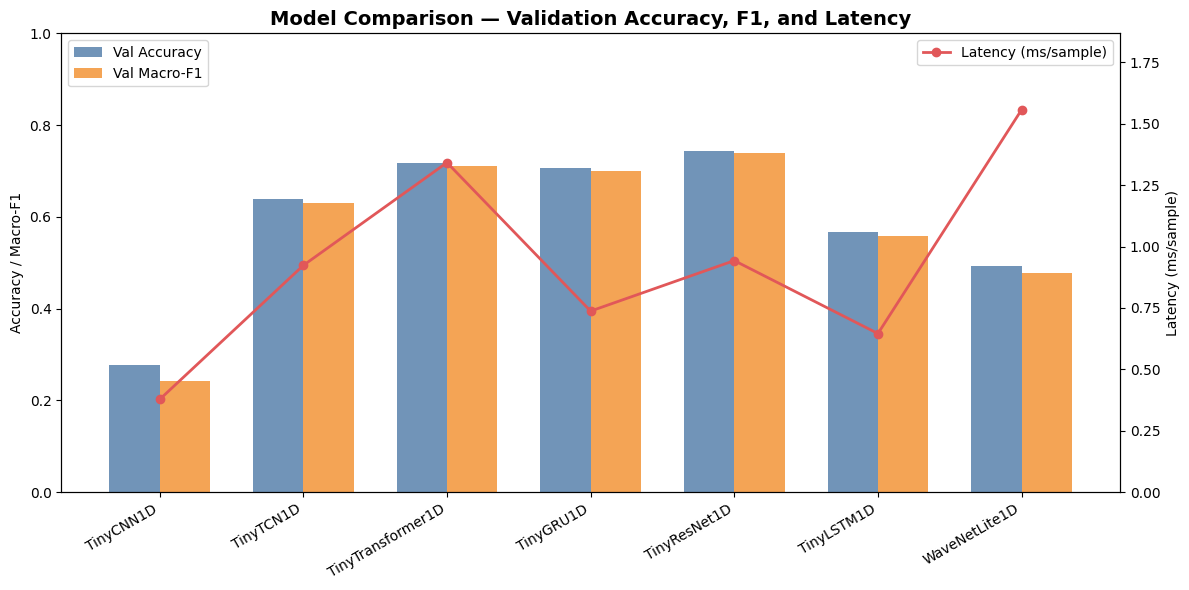

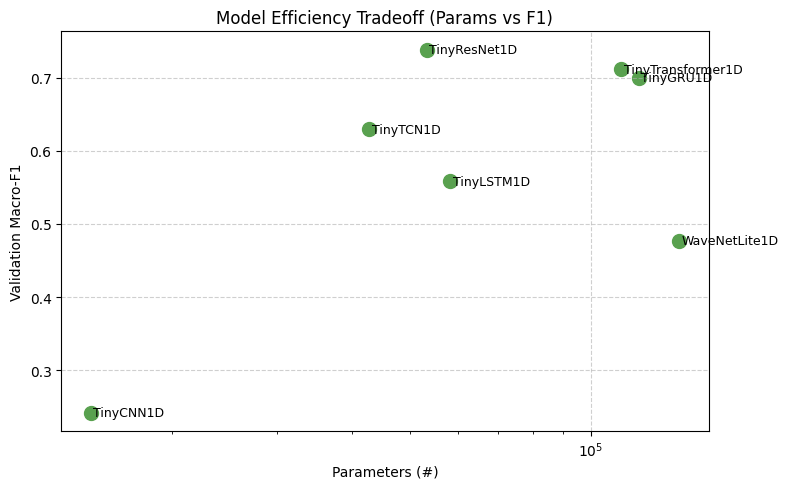

In [ ]:
import matplotlib.pyplot as plt
import json

# Load results
paths = {
    "TinyCNN1D": "/content/drive/MyDrive/sign_models/tinycnn_results.json",
    "TinyTCN1D": "/content/drive/MyDrive/sign_models/tinytcn1d_results.json",
    "TinyTransformer1D": "/content/drive/MyDrive/sign_models/tinytransformer1d_results.json",
    "TinyGRU1D": "/content/drive/MyDrive/sign_models/tinygru1d_results.json",
    "TinyResNet1D": "/content/drive/MyDrive/sign_models/tinyresnet1d_results.json",
    "TinyLSTM1D": "/content/drive/MyDrive/sign_models/tinylstm1d_results.json",
    "WaveNetLite1D": "/content/drive/MyDrive/sign_models/wavenetlite1d_results.json",
}

results = {}
for name, path in paths.items():
    with open(path, "r") as f:
        results[name] = json.load(f)

# Extract metrics
models = list(results.keys())
val_acc = [results[m]["val_acc"] for m in models]
val_f1  = [results[m]["val_f1"] for m in models]
latency = [results[m]["latency_ms"] for m in models]
params  = [results[m]["params"] for m in models]

# Plot setup
plt.figure(figsize=(12, 7))
bar_width = 0.35
x = range(len(models))

# Plot accuracy and F1
fig, ax1 = plt.subplots(figsize=(12, 6))
ax2 = ax1.twinx()

ax1.bar(x, val_acc, width=bar_width, label='Val Accuracy', color='#4e79a7', alpha=0.8)
ax1.bar([i + bar_width for i in x], val_f1, width=bar_width, label='Val Macro-F1', color='#f28e2b', alpha=0.8)

ax1.set_ylabel("Accuracy / Macro-F1")
ax1.set_xticks([i + bar_width/2 for i in x])
ax1.set_xticklabels(models, rotation=30, ha='right')
ax1.set_ylim(0, 1)

# Plot latency on secondary y-axis
ax2.plot([i + bar_width/2 for i in x], latency, color='#e15759', marker='o', linewidth=2, label='Latency (ms/sample)')
ax2.set_ylabel("Latency (ms/sample)")
ax2.set_ylim(0, max(latency)*1.2)

# Titles & legends
ax1.set_title("Model Comparison — Validation Accuracy, F1, and Latency", fontsize=14, weight='bold')
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')

plt.tight_layout()
plt.show()

# plot params vs F1
plt.figure(figsize=(8,5))
plt.scatter(params, val_f1, color='#59a14f', s=100)
for i, name in enumerate(models):
    plt.text(params[i]*1.01, val_f1[i], name, fontsize=9, va='center')
plt.xlabel("Parameters (#)")
plt.ylabel("Validation Macro-F1")
plt.title("Model Efficiency Tradeoff (Params vs F1)")
plt.xscale("log")  # since param counts vary by order of magnitude
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()
